In [138]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [140]:
def fW_eD(t_D, r_eD):

    if t_D < 0.01:
        return (2 / np.sqrt(np.pi)) * np.sqrt(t_D)

    elif 0.01 <= t_D < 200 and t_D < 0.25 * r_eD**2:
        return (
            (1.12838 * np.sqrt(t_D) + 1.19328 * t_D
                 + 0.269872 * t_D * np.sqrt(t_D)
                + 0.00855294 * t_D**2)
                            /
                (1 + 0.616599 * np.sqrt(t_D)
                 + 0.0413008 * t_D)
        )

    elif t_D > 200 and t_D < 0.25 * r_eD**2:
        return (
            (2.02566 * t_D - 4.29881)
                        /
                np.log(t_D)
        )

    elif t_D > 0.25 * r_eD**2:
        factor_term = (r_eD**2 - 1) / 2
        exp_term = np.exp((-2 * t_D)/(((r_eD**2)-1)*(np.log(r_eD) - 0.75)))
        return factor_term * (1 - exp_term)

    else:
        return np.nan

In [142]:
time=[0,75,150,225,300,375,500,750,1000]
pressure=[2700,2650,2627,2568,2540,2485,2440,2371,2316]
ares=3000
aaq=60000
poro=.2
k=400
ha=50
ct=7*10**-6
viscosityw=1
angle=140

In [144]:
f=angle/360
re=np.sqrt(ares*43560/np.pi/f)
ra=np.sqrt(aaq*43560/np.pi/f)
Wei=pressure[0]*ct*np.pi*(ra**2-re**2)*ha*poro*f/5.614
red=ra/re
J=0.007082*k*ha*f/viscosityw/(np.log(red)-0.75)
u=1.119*f*poro*ct*ha*re**2

In [7]:
def Fetkovich(pressure,time,Wei,J):
    pa=pressure[0]
    We=[0]
    for n in range(1,len(pressure)):
        avgp=(pressure[n]+pressure[n-1])/2
        pdiff=pa-avgp
        dwen=Wei/pressure[0]*pdiff*(1-np.exp(-J*pressure[0]/Wei*(time[n]-time[n-1])))
        We.append(dwen+We[n-1])
        pa=pressure[0]*(1-We[n]/Wei)
    return We

In [3]:
#print(Fetkovich(pressure,time,Wei,J))

In [150]:
def VEH(pressure,time,k,poro,viscosityw,ct,re,red,u):
    We_final=[0]
    for n in range(1,len(pressure)):
        prod=0
        for j in range(1,n+1):
            if j <=2:
                dp=0.5*(pressure[0]-pressure[j])
            else:
                dp=0.5*(pressure[j-2]-pressure[j])
            dt=(time[n]-time[j-1])*24
            dtd=0.0002637*k*dt/poro/viscosityw/ct/re**2
            W_eD=fW_eD(dtd,red)
            prod+=dp*W_eD
        We=u*prod
        
        We_final.append(We)
    
    return We_final


In [152]:
#print(VEH(pressure,time,k,poro,viscosityw,ct,re,red,u))

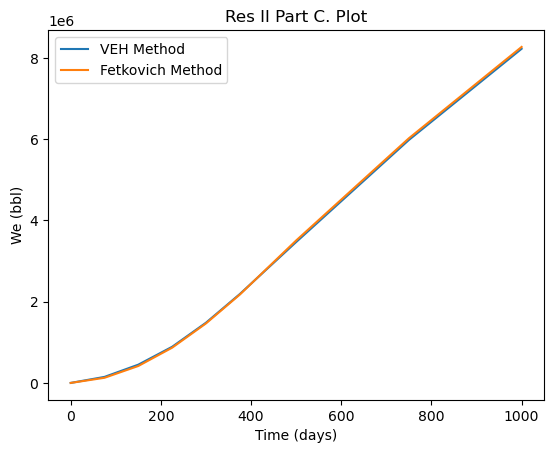

In [170]:
y=VEH(pressure,time,k,poro,viscosityw,ct,re,red,u)
plt.plot(time,y,label='VEH Method')
y=Fetkovich(pressure,time,Wei,J)
plt.plot(time,y,label='Fetkovich Method')
plt.xlabel('Time (days)')
plt.ylabel('We (bbl)')
plt.title ('Res II Part C. Plot',fontsize=12)
plt.legend()
plt.show()